# HR Employee Attrition & Talent Analytics Case Study

## Case Study Objective

The objective of this case study is to analyze employee attrition data and identify the key factors that influence employee resignation.

This project will help HR teams understand:

1. Overall employee attrition rate
2. Department-wise attrition
3. Job role attrition risk
4. Impact of overtime on attrition
5. Impact of salary and experience on attrition
6. Employee risk prediction using machine learning
7. HR business recommendations for retention

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [10]:
total_employees = df.shape[0]

employees_left = df[df['Attrition'] == 'Yes'].shape[0]

employees_stayed = df[df['Attrition'] == 'No'].shape[0]

attrition_rate = employees_left / total_employees * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Employees Stayed:", employees_stayed)
print("Attrition Rate:", round(attrition_rate, 2), "%")

Total Employees: 1470
Employees Left: 237
Employees Stayed: 1233
Attrition Rate: 16.12 %


## Initial Data Understanding

The dataset contains 1470 employee records and 35 columns.

There are no missing values and no duplicate records.

The target variable is Attrition.

The attrition rate is 16.12%, which means the dataset is imbalanced because the number of employees who left is much smaller than the number of employees who stayed.

This is important because accuracy alone will not be enough for model evaluation. For HR attrition prediction, recall, precision, F1-score, and ROC-AUC are more important.

In [11]:
def attrition_summary(data, column):
    summary = data.groupby(column)['Attrition'].agg(
        Total_Employees='count',
        Employees_Left=lambda x: (x == 'Yes').sum()
    )
    
    summary['Employees_Stayed'] = summary['Total_Employees'] - summary['Employees_Left']
    
    summary['Attrition_Rate_%'] = (
        summary['Employees_Left'] / summary['Total_Employees'] * 100
    ).round(2)
    
    return summary.sort_values(by='Attrition_Rate_%', ascending=False)

In [12]:
attrition_summary(df, 'Department')

,Total_Employees,Employees_Left,Employees_Stayed,Attrition_Rate_%
Department,,,,
Sales,446,92,354,20.63
Human Resources,63,12,51,19.05
Research & Development,961,133,828,13.84


In [13]:
attrition_summary(df, 'OverTime')

,Total_Employees,Employees_Left,Employees_Stayed,Attrition_Rate_%
OverTime,,,,
Yes,416,127,289,30.53
No,1054,110,944,10.44


In [14]:
attrition_summary(df, 'JobRole')

,Total_Employees,Employees_Left,Employees_Stayed,Attrition_Rate_%
JobRole,,,,
Sales Representative,83,33,50,39.76
Laboratory Technician,259,62,197,23.94
Human Resources,52,12,40,23.08
Sales Executive,326,57,269,17.48
Research Scientist,292,47,245,16.10
Manufacturing Director,145,10,135,6.90
Healthcare Representative,131,9,122,6.87
Manager,102,5,97,4.90
Research Director,80,2,78,2.50


## Early Business Insights

1. The overall attrition rate is 16.12%.

2. Sales department has the highest attrition rate among departments.

3. Employees working overtime show a much higher attrition rate compared to employees not working overtime.

4. Some job roles, especially Sales Representative and Laboratory Technician, show higher attrition risk.

5. HR should focus on workload, overtime, job role pressure, salary, and employee satisfaction to reduce attrition.

In [15]:
# Set Chart Style
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

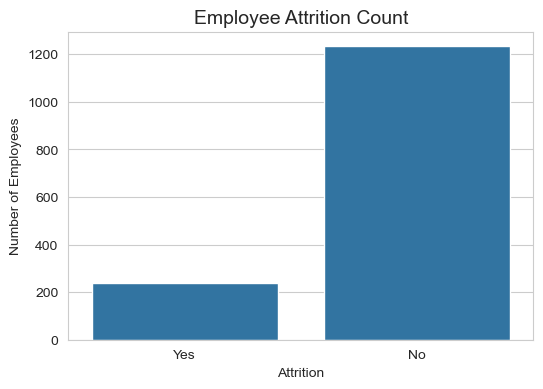

In [16]:
# Attrition Count Chart
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Attrition')

plt.title("Employee Attrition Count", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

# Most employees stayed in the company. Only a smaller group left the company.

# This confirms that the dataset is imbalanced.

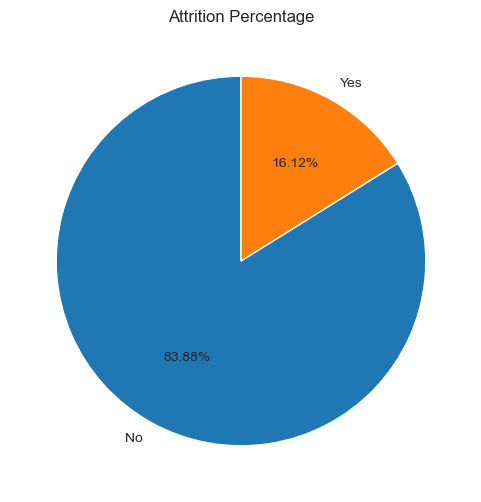

In [17]:
# Attrition Percentage Pie Chart
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Attrition Percentage")
plt.show()

# Sales department shows the highest attrition rate.

# HR should investigate pressure, targets, incentives, and workload in the Sales department.

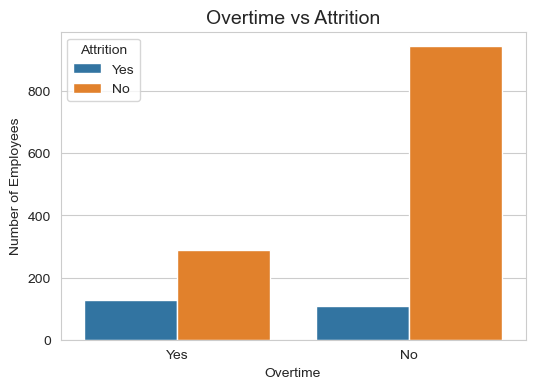

In [18]:
# Time vs Attrition
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='OverTime', hue='Attrition')

plt.title("Overtime vs Attrition", fontsize=14)
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.show()

# Employees working overtime are more likely to leave the company.

# Overtime is one of the strongest attrition risk factors.

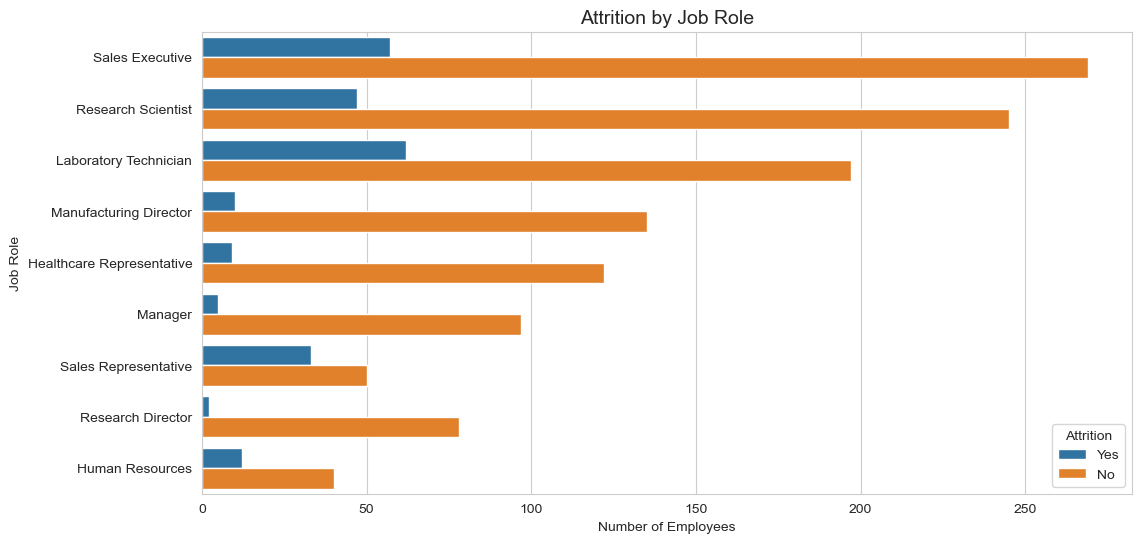

In [19]:
# Job Role vs Attrition
plt.figure(figsize=(12,6))

sns.countplot(data=df, y='JobRole', hue='Attrition')

plt.title("Attrition by Job Role", fontsize=14)
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.show()

# Sales Representative, Laboratory Technician, and Human Resources roles show higher attrition risk.

# HR should create role-specific retention strategies.

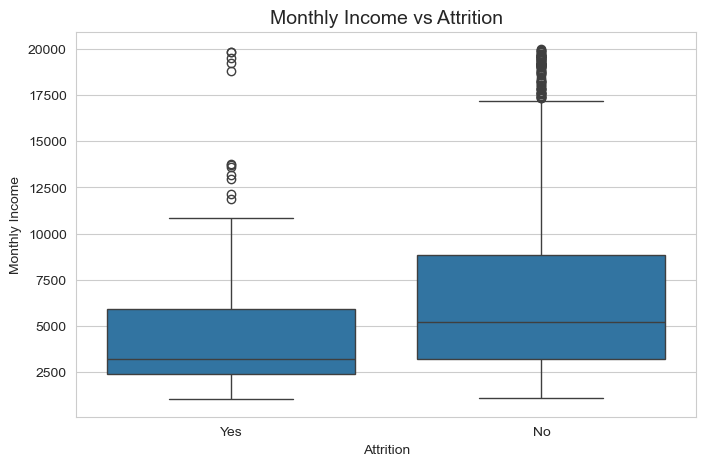

In [20]:
# Monthly Income vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')

plt.title("Monthly Income vs Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

# Employees who leave generally have lower monthly income compared to employees who stay.

# Salary and compensation may be important retention factors.

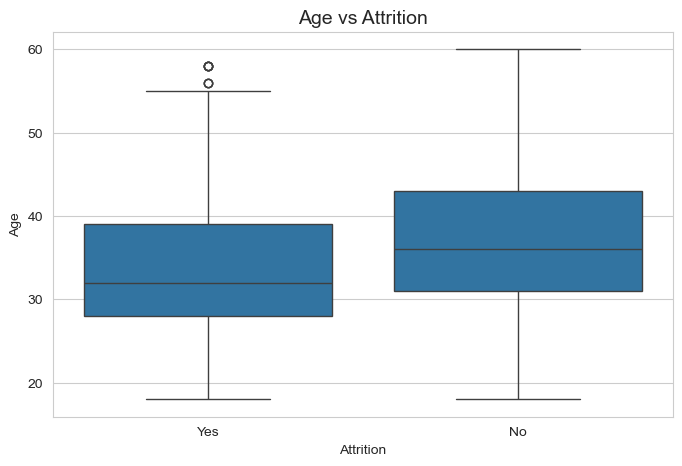

In [21]:
# Age vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Attrition', y='Age')

plt.title("Age vs Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

# Younger employees show higher attrition tendency.

# Early-career employees may need better mentoring, career growth, and engagement.

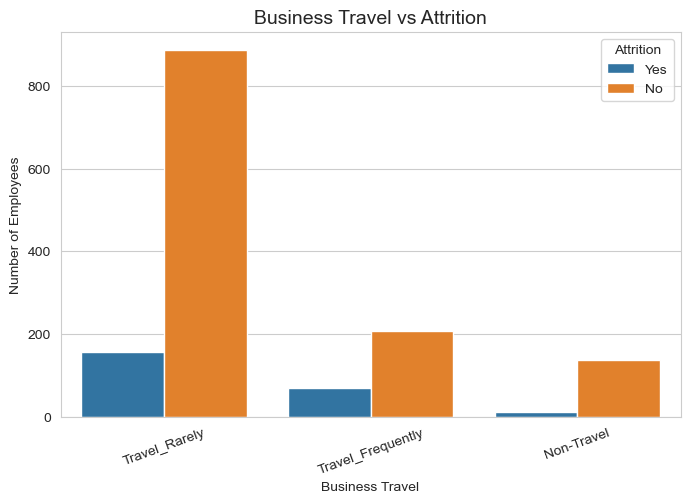

In [22]:
# Business Travel vs Attrition
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='BusinessTravel', hue='Attrition')

plt.title("Business Travel vs Attrition", fontsize=14)
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")
plt.xticks(rotation=20)

plt.show()

# Employees who travel frequently may have higher attrition risk.

# Frequent travel can affect work-life balance and job satisfaction.

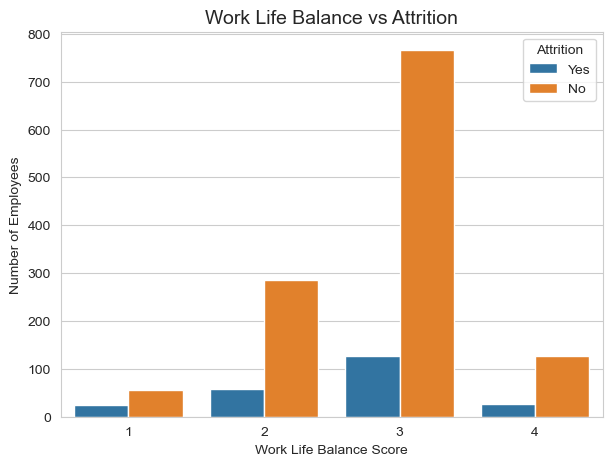

In [23]:
# Work Life Balance vs Attrition
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition')

plt.title("Work Life Balance vs Attrition", fontsize=14)
plt.xlabel("Work Life Balance Score")
plt.ylabel("Number of Employees")

plt.show()

# Poor work-life balance can increase attrition risk.

# HR should focus on workload management and employee wellness.

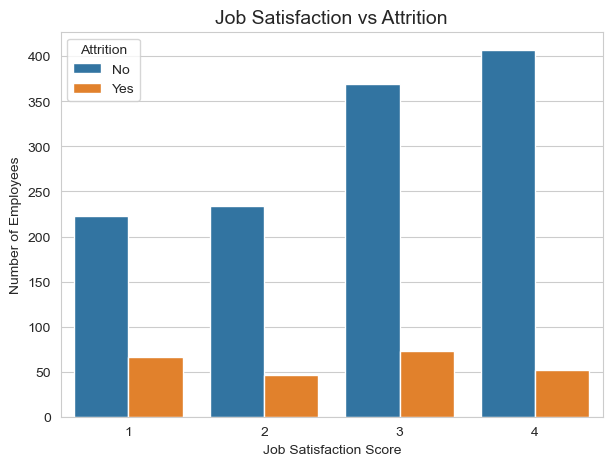

In [24]:
# Job Satisfaction vs Attrition
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')

plt.title("Job Satisfaction vs Attrition", fontsize=14)
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Employees")

plt.show()

# Employees with lower job satisfaction are more likely to leave.

# Regular employee feedback and satisfaction surveys can help reduce attrition.

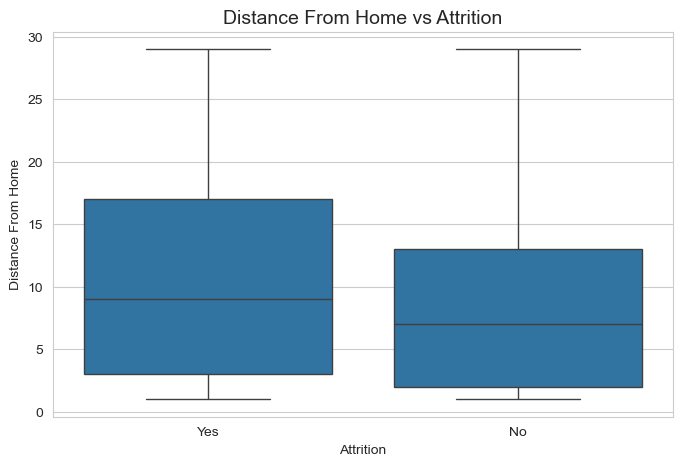

In [25]:
# Distance From Home vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')

plt.title("Distance From Home vs Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")

plt.show()

# Employees living farther from the workplace may have higher resignation risk because of commute burden.

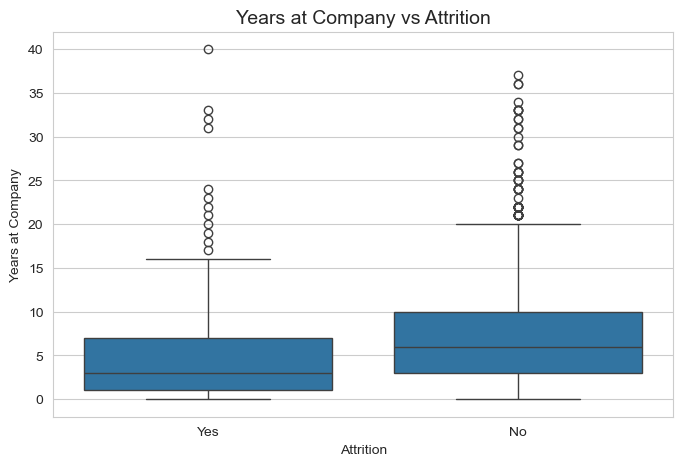

In [26]:
# Years at Company vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')

plt.title("Years at Company vs Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

# Employees with fewer years at the company are more likely to leave.

# The first few years are very important for retention.

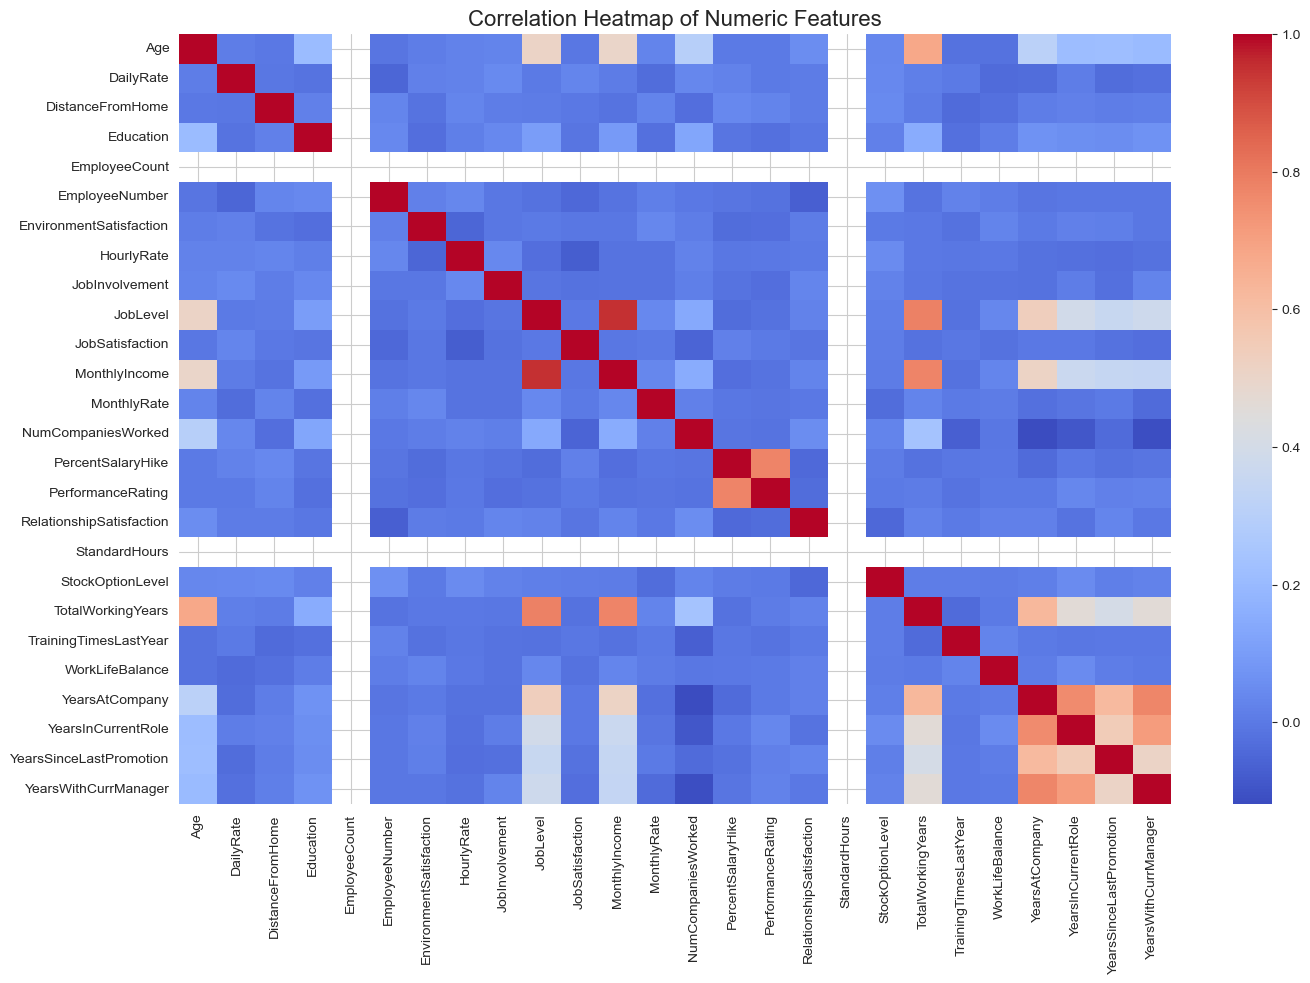

In [27]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(16,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=16)

plt.show()

# Phase 5: Exploratory Data Analysis Summary

## Key Findings

1. The overall attrition rate is 16.12%.

2. Sales department has higher attrition compared to other departments.

3. Overtime is a strong attrition driver. Employees working overtime show much higher attrition risk.

4. Sales Representative and Laboratory Technician roles show high attrition.

5. Younger employees and early-career employees are more likely to leave.

6. Employees with lower monthly income show higher attrition risk.

7. Poor work-life balance and low job satisfaction may increase employee resignation risk.

8. Distance from home may also contribute to attrition because of commute burden.

## Senior Data Scientist Observation

Attrition is not randomly distributed. It is concentrated among specific employee groups such as overtime workers, sales employees, younger employees, low-income employees, and employees with shorter tenure.

This means HR should use targeted retention strategies instead of applying the same policy to all employees.

In [29]:
# Save Clean Dataset
df.to_csv("HR_Attrition_Clean_Data.csv", index=False)

# Feature Engineering

In [34]:
df['Attrition_Flag'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

df[['Attrition', 'Attrition_Flag']].head()

,Attrition,Attrition_Flag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [31]:
# Create Age Group

def age_group(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    else:
        return '46-60'

df['Age_Group'] = df['Age'].apply(age_group)

df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,41,36-45
1,49,46-60
2,37,36-45
3,33,26-35
4,27,26-35


In [35]:
def income_group(income):
    if income <= 3000:
        return 'Low Income'
    elif income <= 5000:
        return 'Lower-Middle Income'
    elif income <= 8000:
        return 'Middle Income'
    elif income <= 12000:
        return 'Upper-Middle Income'
    else:
        return 'High Income'

df['Income_Group'] = df['MonthlyIncome'].apply(income_group)

df[['MonthlyIncome', 'Income_Group']].head()

,MonthlyIncome,Income_Group
0,5993,Middle Income
1,5130,Middle Income
2,2090,Low Income
3,2909,Low Income
4,3468,Lower-Middle Income


In [36]:
def tenure_group(years):
    if years <= 2:
        return '0-2 Years'
    elif years <= 5:
        return '3-5 Years'
    elif years <= 10:
        return '6-10 Years'
    else:
        return '10+ Years'

df['Tenure_Group'] = df['YearsAtCompany'].apply(tenure_group)

df[['YearsAtCompany', 'Tenure_Group']].head()

,YearsAtCompany,Tenure_Group
0,6,6-10 Years
1,10,6-10 Years
2,0,0-2 Years
3,8,6-10 Years
4,2,0-2 Years


In [38]:
df[['Attrition', 'Attrition_Flag',
    'Age', 'Age_Group',
    'MonthlyIncome', 'Income_Group',
    'YearsAtCompany', 'Tenure_Group',
    'TotalWorkingYears']].head()

,Attrition,Attrition_Flag,Age,Age_Group,MonthlyIncome,Income_Group,YearsAtCompany,Tenure_Group,TotalWorkingYears
0,Yes,1,41,36-45,5993,Middle Income,6,6-10 Years,8
1,No,0,49,46-60,5130,Middle Income,10,6-10 Years,10
2,Yes,1,37,36-45,2090,Low Income,0,0-2 Years,7
3,No,0,33,26-35,2909,Low Income,8,6-10 Years,8
4,No,0,27,26-35,3468,Lower-Middle Income,2,0-2 Years,6


In [39]:
df.to_csv("HR_Attrition_Feature_Engineered.csv", index=False)

# Phase 6: Feature Engineering Summary

In this phase, we created new columns to make the HR data easier to understand.

New columns created:

1. Attrition_Flag
   - Yes converted to 1
   - No converted to 0

2. Age_Group
   - Employees divided into age groups

3. Income_Group
   - Employees divided into salary groups

4. Tenure_Group
   - Employees divided by years at company

5. Experience_Group
   - Employees divided by total work experience

These new columns help HR understand attrition patterns more clearly.

# Phase 7: Machine Learning
Simple Meaning

In this phase, we teach the computer to predict:

Will employee leave the company?
Yes or No

Our target column is:

Attrition

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Create ML copy
ml_df = df.copy()

# Remove columns not useful for prediction
ml_df = ml_df.drop(columns=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
], errors='ignore')

# Use Attrition_Flag as target
y = ml_df['Attrition_Flag']

# Remove target columns from input
X = ml_df.drop(columns=['Attrition', 'Attrition_Flag'])

# Convert text columns into numbers
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create model
model = RandomForestClassifier(
    random_state=42,
    n_estimators=300
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", str(round(accuracy * 100, 2)) + "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 82.65%

Confusion Matrix:
[[239   8]
 [ 43   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



# Phase 7: Machine Learning Model Building

In this phase, a Random Forest classification model was created to predict employee attrition.

The target column is Attrition.

Before model training, unnecessary columns such as EmployeeCount, EmployeeNumber, Over18, and StandardHours were removed.

Text columns were converted into numerical format using Label Encoding.

The dataset was split into training and testing data using an 80:20 ratio.

A Random Forest model was trained on the training data and tested on unseen test data.

The model performance was evaluated using accuracy, confusion matrix, and classification report.

# Phase 8: Model Evaluation
Simple Meaning

In this phase, we check:

How good is our model?
Is it only giving high accuracy?
Or is it really finding employees who may leave?

For HR attrition, accuracy is not enough because only 16.12% employees left.

So we check:

Metric	Meaning
Accuracy	Total correct predictions
Precision	When model says “employee will leave”, how correct it is
Recall	Out of actual employees who left, how many model found
F1-score	Balance of precision and recall
Confusion Matrix	Correct and wrong predictions
 Step 1: Check Model Accuracy Again

In [45]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", str(round(accuracy * 100, 2)) + "%")

Model Accuracy: 82.65%


In [46]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[239   8]
 [ 43   4]]


In [49]:
# | Value | Meaning                                


#TN    Employee stayed, model predicted stayed 
#FP    Employee stayed, model predicted leave  
#FN    Employee left, model missed             
#TP    Employee left, model predicted leave    


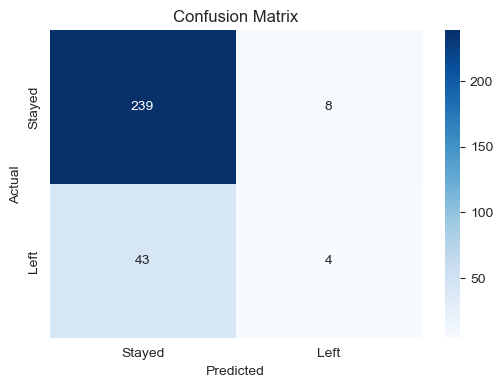

In [50]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Left'],
    yticklabels=['Stayed', 'Left']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



# Phase 8: Model Evaluation

The Random Forest model was evaluated using accuracy, confusion matrix, precision, recall, and F1-score.

Because the attrition dataset is imbalanced, accuracy alone is not enough.

In HR attrition prediction, recall for employees who left is very important because the business goal is to identify employees who may resign.

A high accuracy model may still be weak if it fails to detect actual attrition cases.

Therefore, model performance should be interpreted using both classification report and confusion matrix.

In [52]:
# Feature Importance

# This tells us which columns helped the model most.

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,MonthlyIncome,0.068449
0,Age,0.057509
16,TotalWorkingYears,0.055850
1,DailyRate,0.048633
10,MonthlyRate,0.044906
2,DistanceFromHome,0.043685
5,HourlyRate,0.043378
19,YearsAtCompany,0.039776
43,OverTime_Yes,0.037860
11,NumCompaniesWorked,0.035227


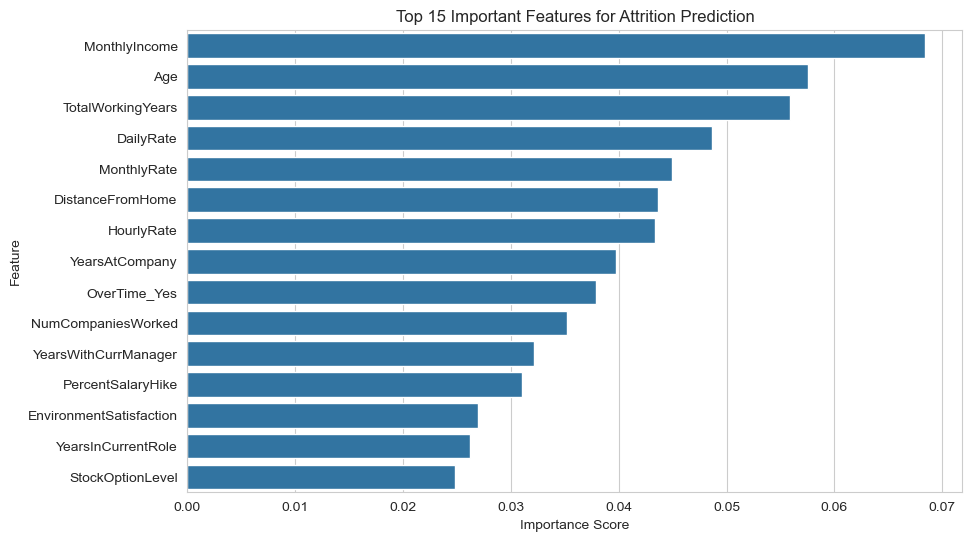

In [53]:
# Feature Importance Chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features for Attrition Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Feature Importance Interpretation

The feature importance chart shows which factors are most useful for predicting employee attrition.

Important factors may include:

1. Monthly Income
2. Age
3. Overtime
4. Job Role
5. Total Working Years
6. Years at Company
7. Distance From Home
8. Job Satisfaction
9. Environment Satisfaction
10. Work Life Balance

These factors help HR understand which employee characteristics are connected with resignation risk.

In [55]:
# Check Prediction Probability

# This gives risk percentage.

y_prob = model.predict_proba(X_test)[:, 1]

y_prob[:10]


array([0.58666667, 0.09      , 0.15666667, 0.02333333, 0.27333333,
       0.06666667, 0.06      , 0.05333333, 0.02333333, 0.52      ])

In [56]:
results_df = X_test.copy()

results_df['Actual_Attrition'] = y_test.values
results_df['Predicted_Attrition'] = y_pred
results_df['Attrition_Risk_Probability'] = y_prob
results_df['Attrition_Risk_%'] = (y_prob * 100).round(2)

results_df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Income_Group_Lower-Middle Income,Income_Group_Middle Income,Income_Group_Upper-Middle Income,Tenure_Group_10+ Years,Tenure_Group_3-5 Years,Tenure_Group_6-10 Years,Actual_Attrition,Predicted_Attrition,Attrition_Risk_Probability,Attrition_Risk_%
1061,24,830,13,2,4,78,3,1,2,2033,...,False,False,False,False,False,False,0,1,0.586667,58.67
891,44,1117,2,1,1,72,4,1,4,2011,...,False,False,False,False,False,True,0,0,0.090000,9.00
456,31,688,7,3,3,44,2,3,4,11557,...,False,False,True,False,True,False,0,0,0.156667,15.67
922,44,1199,4,2,3,92,4,5,1,19190,...,False,False,False,True,False,False,0,0,0.023333,2.33
69,36,318,9,3,4,79,2,1,3,3388,...,True,False,False,False,False,False,1,0,0.273333,27.33


In [57]:
def risk_category(probability):
    if probability >= 0.70:
        return 'High Risk'
    elif probability >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results_df['Risk_Category'] = results_df['Attrition_Risk_Probability'].apply(risk_category)

results_df[['Actual_Attrition', 'Predicted_Attrition', 'Attrition_Risk_%', 'Risk_Category']].head()

,Actual_Attrition,Predicted_Attrition,Attrition_Risk_%,Risk_Category
1061,0,1,58.67,Medium Risk
891,0,0,9.00,Low Risk
456,0,0,15.67,Low Risk
922,0,0,2.33,Low Risk
69,1,0,27.33,Low Risk


In [58]:
results_df['Risk_Category'].value_counts()

Risk_Category
Low Risk       273
Medium Risk     18
High Risk        3
Name: count, dtype: int64

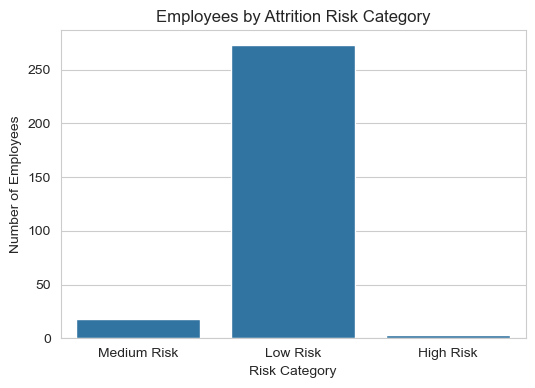

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(data=results_df, x='Risk_Category')

plt.title("Employees by Attrition Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")

plt.show()

In [60]:
results_df.to_csv("HR_Model_Evaluation_Output.csv", index=False)

# Phase 8 Summary

In this phase, the trained Random Forest model was evaluated.

The model performance was checked using:

1. Accuracy
2. Confusion Matrix
3. Classification Report
4. Feature Importance
5. Prediction Probability
6. Risk Category

The most important point is that HR attrition prediction should not depend only on accuracy.

Recall and risk probability are very useful because HR wants to identify employees who may leave before they actually resign.

The model output can be converted into risk categories such as Low Risk, Medium Risk, and High Risk.

In [61]:
# Phase 9: Employee Attrition Risk Scoring

# Predict risk probability for all employees
risk_probability = model.predict_proba(X)[:, 1]

# Create risk dataframe from original data
df_risk = df.copy()

# Add risk probability
df_risk['Attrition_Risk_Probability'] = risk_probability
df_risk['Attrition_Risk_%'] = (risk_probability * 100).round(2)

# Create risk category
def risk_category(probability):
    if probability >= 0.70:
        return 'High Risk'
    elif probability >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_risk['Risk_Category'] = df_risk['Attrition_Risk_Probability'].apply(risk_category)

# Add HR action recommendation
def hr_action(row):
    if row['Risk_Category'] == 'High Risk':
        return 'Immediate HR intervention required'
    elif row['Risk_Category'] == 'Medium Risk':
        return 'Monitor and conduct engagement check-in'
    else:
        return 'Normal monitoring'

df_risk['HR_Action'] = df_risk.apply(hr_action, axis=1)

# Create final Power BI output
final_risk_output = df_risk[[
    'EmployeeNumber',
    'Age',
    'Gender',
    'Department',
    'JobRole',
    'MonthlyIncome',
    'OverTime',
    'BusinessTravel',
    'DistanceFromHome',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'WorkLifeBalance',
    'YearsAtCompany',
    'TotalWorkingYears',
    'Attrition',
    'Attrition_Risk_%',
    'Risk_Category',
    'HR_Action'
]]

# Show top 20 risky employees
top_risk_employees = final_risk_output.sort_values(
    by='Attrition_Risk_%',
    ascending=False
)

top_risk_employees.head(20)

,EmployeeNumber,Age,Gender,Department,JobRole,MonthlyIncome,OverTime,BusinessTravel,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,Attrition,Attrition_Risk_%,Risk_Category,HR_Action
463,622,26,Male,Research & Development,Laboratory Technician,2340,Yes,Travel_Rarely,24,4,3,1,1,1,Yes,94.00,High Risk,Immediate HR intervention required
127,167,19,Male,Sales,Sales Representative,1675,Yes,Travel_Rarely,22,3,4,2,0,0,Yes,93.67,High Risk,Immediate HR intervention required
1332,1868,29,Male,Research & Development,Research Scientist,2439,Yes,Travel_Frequently,24,4,4,2,1,1,Yes,91.33,High Risk,Immediate HR intervention required
1153,1624,18,Female,Sales,Sales Representative,1569,Yes,Travel_Frequently,3,4,2,4,0,0,Yes,91.00,High Risk,Immediate HR intervention required
1012,1427,31,Female,Sales,Sales Representative,1359,No,Travel_Frequently,1,3,2,3,1,1,Yes,91.00,High Risk,Immediate HR intervention required
457,614,18,Male,Sales,Sales Representative,1878,Yes,Travel_Frequently,5,2,2,3,0,0,Yes,90.33,High Risk,Immediate HR intervention required
171,235,19,Female,Sales,Sales Representative,2325,No,Travel_Frequently,1,1,3,4,0,1,Yes,90.00,High Risk,Immediate HR intervention required
1365,1928,29,Male,Sales,Sales Representative,1091,No,Travel_Frequently,24,1,3,3,1,1,Yes,90.00,High Risk,Immediate HR intervention required
1136,1604,28,Male,Research & Development,Laboratory Technician,2408,Yes,Travel_Rarely,24,2,3,3,1,1,Yes,89.00,High Risk,Immediate HR intervention required
892,1248,19,Female,Research & Development,Research Scientist,1859,Yes,Non-Travel,10,2,1,4,1,1,Yes,89.00,High Risk,Immediate HR intervention required


In [62]:
final_risk_output.to_csv("HR_Employee_Attrition_Risk_Scoring.csv", index=False)

# Phase 9: Employee Attrition Risk Scoring

In this phase, the trained machine learning model was used to calculate attrition risk probability for each employee.

The probability was converted into a percentage and classified into three risk categories:

1. Low Risk
2. Medium Risk
3. High Risk

An HR action recommendation was also added for each employee.

High-risk employees require immediate HR intervention, medium-risk employees require engagement check-ins, and low-risk employees require normal monitoring.

The final risk scoring output was saved as a CSV file for Power BI dashboard creation.